In [1]:
# reload modules before execution (for the changing code in src)
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

sys.path.append(str(Path.cwd().parent))
import src.utils as utils
from src.palettes import peacock_map_palette

countries_db_name = '../data/processed/countries.db'
findex_db_name = '../data/raw/Findex.db'
sql_folder = '../sql/'

world_file = '../data/raw/geodata/ne_10m_admin_0_countries.zip'

In [3]:
# available Findex waves
waves = [2011, 2014, 2017, 2021, 2024]

In [266]:
def plot_buckets_countries(no_buckets, 
                           data, 
                           value_col_name, 
                           palette,
                          title):
    '''
    series is assumed to have percentages,
    series values is for (observation_date, country)
    buckets are uniform within 0-100 range
    '''
    plot_data = data.copy()
    
    # plotting percentages
    min_range = 0
    max_range = 100
    # assign a bucket, range divided uniformly
    plot_data['clusters'], edges = utils.divide_range_into_buckets(no_buckets, min_range, max_range, data[value_col_name])

    # recover categories
    categories = np.sort(plot_data['clusters'].dropna().astype(int).unique())

    # prepare labels
    labels = prepare_labels(edges, categories)

    waves = np.sort(plot_data['observation_date'].unique())
    
    plot_data = plot_data[['country', 'observation_date', 'clusters']].pivot(index = 'country', columns = 'observation_date', values = 'clusters')
    plot_data.columns.name = None
    plot_data['clusters_combined'] = plot_data[waves[-1:0:-1]].bfill(axis = 1).iloc[:,0]

    plot_palette = dict(zip(categories, palette))
    
    utils.plot_cluster_map(plot_data['clusters_combined'], 
        labels = labels, 
        palette = plot_palette,
        title = title
    )

In [269]:
def plot_Gaussian_buckets_countries(data, value_col_name, palette, title):
    '''
    series is assumed to have percentages,
    series values is for (observation_date, country)
    '''
    plot_data = data.copy()
    
    # plotting percentages
    min_range = 0
    max_range = 100
    # assign a bucket, range divided uniformly
    plot_data['clusters'], edges = utils.divide_range_into_Gaussian_buckets(data[value_col_name])

    # recover categories
    categories = np.sort(plot_data['clusters'].dropna().astype(int).unique())

    # prepare labels
    labels = prepare_labels(edges, categories)

    waves = np.sort(plot_data['observation_date'].unique())
    
    plot_data = plot_data[['country', 'observation_date', 'clusters']].pivot(index = 'country', columns = 'observation_date', values = 'clusters')
    plot_data.columns.name = None
    plot_data['clusters_combined'] = plot_data[waves[-1:0:-1]].bfill(axis = 1).iloc[:,0]

    plot_palette = dict(zip(categories, palette))
    
    utils.plot_cluster_map(plot_data['clusters_combined'], 
        labels = labels, 
        palette = plot_palette,
        title = title
    )

# Percentage of women who pay bills worldwide

## Import data
### fin30.1 "Made a utility payment, women (% age 15+)"

In [256]:
fin30_female_tuples = utils.run_sql(countries_db_name, sql_folder + 'fin30_female.sql')
fin30_female = pd.DataFrame(fin30_female_tuples, columns = ['country_id', 'year', 'val'])

assert not fin30_female.empty

fin30_female['year'] = fin30_female['year'].astype(int)
# Findex 2021 wave includes observations collected in 2022
# treat 2022 observations as part of the 2021 wave
fin30_female.loc[fin30_female['year'] == 2022, 'year'] = 2021

# check for duplicate rows after remapping
assert not fin30_female.duplicated(['country_id', 'year']).any(), (
    "Multiple observations for (country, wave) found."
)

# check observations fall into waves
assert set(fin30_female['year']) <= set(waves), (
    f"Unexpected observation dates found: {set(fin30_female['year']) - set(waves)}"
)

### Plot maps

In [268]:
palette = [
    "#E5D1B8",  # soft beige
    "#C2956E",  # muted sand
    "#DD8E58",  # warm orange
    "#708A81",  # muted sage
    "#2B2129",  # dark plum
]

In [260]:
fin30_female.rename(columns = {'country_id': 'country', 'year': 'observation_date'}, inplace = True)

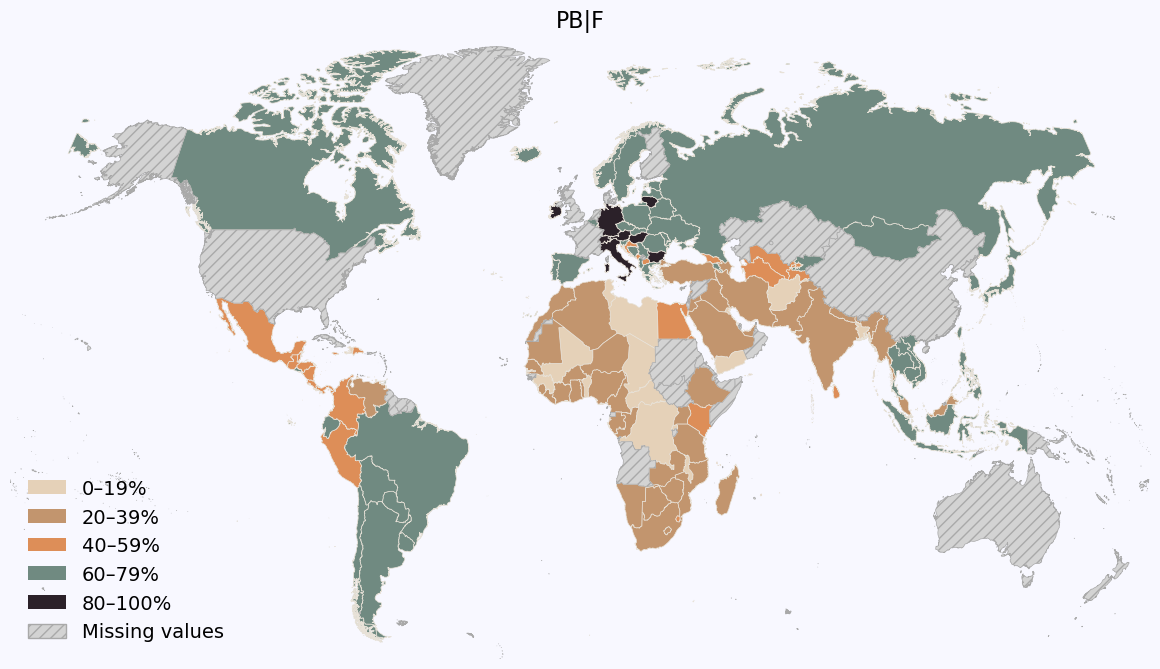

In [265]:
plot_buckets_countries(5, fin30_female[['country', 'observation_date', 'val']], 'val', palette, 'PB|F')

# What percentage of people pay bills worldwide?

### fin30 "Made a utility payment, total (% age 15+)"

In [33]:
# import data from the database
fin30_tuples = utils.run_sql(countries_db_name, sql_folder + 'fin30.sql')
fin30_data = pd.DataFrame(fin30_tuples, columns = ['country_id', 'wave', 'perc_val'])
assert not fin30_data.empty

# observation for 2021 wave were gathered in 2021 and 2022
# make observations representative of the wave
fin30_data['wave'] = fin30_data['wave'].astype(int)
fin30_data.loc[fin30_data['wave'] == 2022, 'wave'] = 2021

# after remapping dates in 2021 wave check for duplicate entries
assert not fin30_data.duplicated(['country_id', 'wave']).any()

# assert valid waves
waves_in_data = np.sort(fin30_data['wave'].unique())
assert set(waves) >= set(waves_in_data)

missing_waves = set(waves) - set(waves_in_data)

In [271]:
fin30_data.rename(columns = {'country_id': 'country', 'wave': 'observation_date'}, inplace = True)

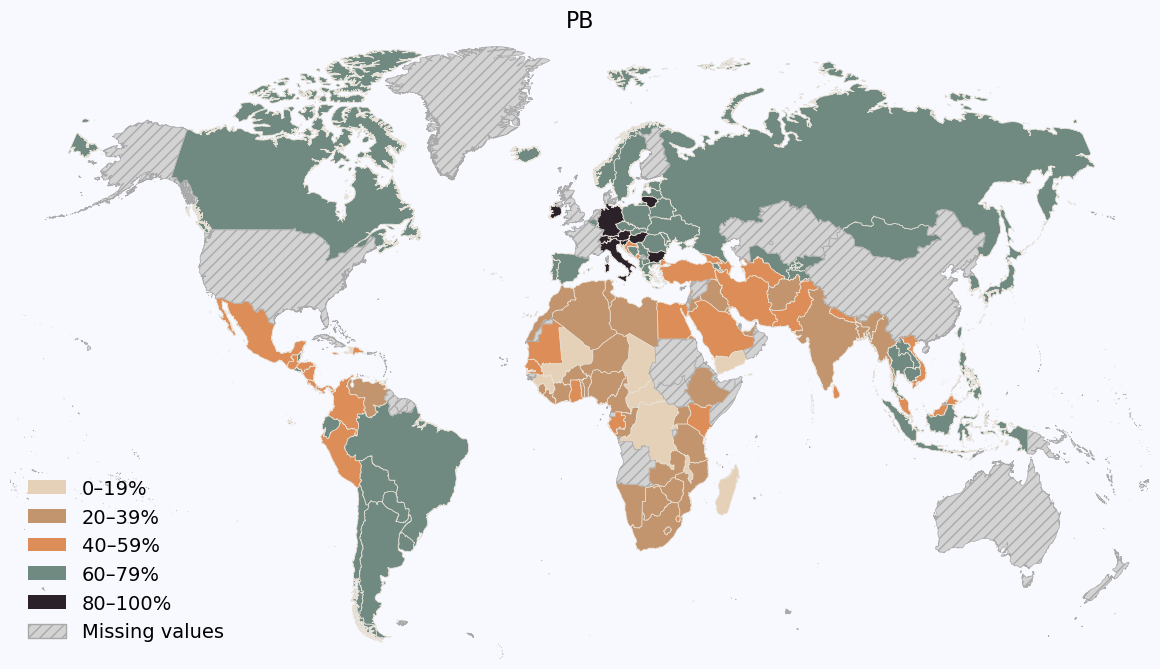

In [272]:
plot_buckets_countries(5, fin30_data[['country', 'observation_date', 'perc_val']], 'perc_val', palette, 'PB')

### Additional info for people who pay bills exploration

In [14]:
# paired observation values, for additional info and base series for (country, date)
# fin31.* series with additional info pair
# fin31.* is "Made utility payment..."
fin31_paired_info_tuples = utils.run_sql(countries_db_name, sql_folder + 'paired_additional_info.sql')
fin31_paired_data = pd.DataFrame(fin31_paired_info_tuples, columns = ['country_id', 'observation_date', 's_id', 's_val', 'base_id', 'base_val'])

# sanity check loaded fin31 group series paired data
assert not fin31_paired_data.empty, (
    f"No data imported from {countreis_db_name}"
)

# sanity check paired fin31 data completeness
assert fin31_paired_data.notna().all().all()

In [15]:
# check if no denominator 0s present
assert not (fin31_paired_data['s_val'] == 0).all(), (
    f"Division by 0 about to happen."
)

# calculate latent values 'ratio of people who payed utility bills'
# using conditional probability
fin31_paired_data['latent'] = fin31_paired_data['base_val']/fin31_paired_data['s_val']

In [16]:
# recover latent values per (country, wave)
fin31_latent = fin31_paired_data[['country_id', 'observation_date', 'latent']].copy()
# convert latent from float ratio to percent
fin31_latent['latent'] = (fin31_latent['latent'].round(2) * 100).astype(int)
# trim observation date to meaningful year
fin31_latent['observation_date'] = fin31_latent['observation_date'].str.slice(stop = 4)
fin31_latent['observation_date'] = pd.to_numeric(fin31_latent['observation_date'])

# recover unique values per (country, year)
# multiple values are present because each value is calculated
# from up to 4 series
fin31_latent.drop_duplicates(inplace = True)

# observation for 2021 wave were gathered in 2021 and 2022
# make observations representative of the wave
fin31_latent.loc[fin31_latent['observation_date'] == 2022, 'observation_date'] = 2021

To be sure, validation is performed: same data is queried from database available at data360 interface from World Bank.
The most important check is the spread.
If assumptions of ability to recover latent data using conditional probability formulas are correct, one should observe 0 spreads per (country, wave) throughout relevant series, where spread is max difference between latent values per (country, wave).

In [17]:
fin31_check_data_tuples = utils.run_sql(findex_db_name, sql_folder + 'fin31_latent.sql')
fin31_check_data = pd.DataFrame(fin31_check_data_tuples, columns = ['country_id', 'wave', 'latent', 'spread'])
# convert year to a numeric
fin31_check_data['wave'] = pd.to_numeric(fin31_check_data['wave'])
# round spread to 10 decimal places
# to account for floating point arithmetic in DB
# and to reflect tolerance for difference < 1e-10
fin31_check_data['spread'] = fin31_check_data['spread'].round(10)
# convert latent to integer percentages
fin31_check_data['latent'] = (fin31_check_data['latent'].round(2) * 100).astype(int)

In [18]:
# all spreads should be 0
gt0_spread_no = (fin31_check_data['spread'] > 0).sum()

assert gt0_spread_no == 0, (
    f"Expected all spreads to be 0, but found {gt0_spread_no} spreads > 0."
)

In [19]:
# data between databases should be equal
temp = pd.merge(fin31_check_data, fin31_latent, left_on = ['country_id', 'wave'], right_on = ['country_id', 'observation_date'])
different_no = (temp['latent_x'] != temp['latent_y']).sum()
assert different_no == 0, (
    f"Got {different_no} differences in data."
)

### Compare World Bank data to calculated data (percentage of population that paid bills)
fin30 from The World Bank is compared to data calculated from fin31 group of indicators.

In [20]:
# 2011 doesn't have any observations
waves = [2014, 2017, 2021, 2024]

In [21]:
paired_latent_official = pd.merge(fin30_data, fin31_latent, left_on = ['country_id', 'wave'], right_on = ['country_id', 'observation_date'], how = 'outer')

assert paired_latent_official['perc_val'].isna().sum() == 0
assert paired_latent_official['latent'].isna().sum() == len(fin30_data) - len(fin31_latent)

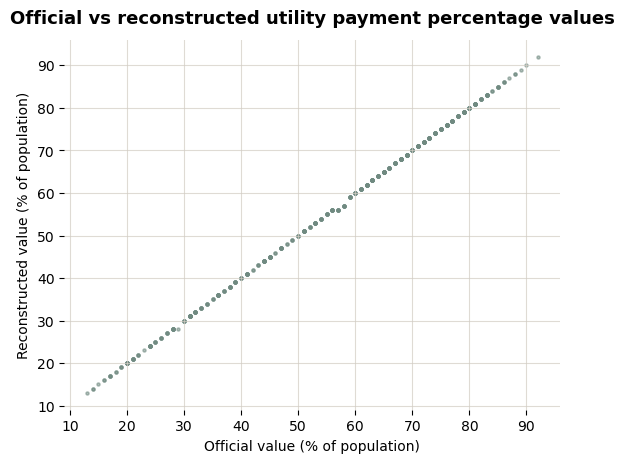

In [22]:
both_available_mask = paired_latent_official[['perc_val', 'latent']].notna().all(axis = 1)
assert both_available_mask.sum() == len(fin31_latent)
scatter_data = paired_latent_official[both_available_mask]

fig, ax = plt.subplots()

ax.scatter(
    scatter_data['perc_val'], scatter_data['latent'],
    s=5, alpha=0.55, color='#708A81'
)

#ax.set_aspect('equal')

ax.set_xlabel('Official value (% of population)')
ax.set_ylabel('Reconstructed value (% of population)')

ax.set_title(
    'Official vs reconstructed utility payment percentage values',
    fontsize=13,
    weight = 'bold',
    pad=12
)

ax.grid(True, color='#D2CCC3', linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

### Check if calculated data contains more or less data points

Official fin30 contains more data than one can calculate from fin31 group of indicators.

In [23]:
# Coverage table for inferred vs official FIN31 availability
#
# Codes:
#   0 = neither available
#   1 = official only
#   2 = inferred only
#   3 = both available

avail = {'neither': 0, 'official': 1, 'inferred': 2, 'both': 3}

assert not fin31_latent.duplicated(['country_id', 'observation_date']).any(), (
    "fin31_latent has multiple (country, wave) values."
)

assert not fin30_data.duplicated(['country_id', 'wave']).any(), (
    "fin30_data has multiple (country, wave) values."
)

countries = sorted(set(fin31_latent['country_id']) | set(fin30_data['country_id']))

# inferred values available per wave
coverage_inferred = (fin31_latent[['country_id', 'observation_date']]
    .assign(inf = avail['inferred'])
    .pivot(index = 'country_id', columns = 'observation_date', values = 'inf'))

# official values available per wave
coverage_official = (fin30_data[['country_id', 'wave']]
    .assign(off = avail['official'])
    .pivot(index = 'country_id', columns = 'wave', values = 'off'))

coverage = (coverage_official.add(coverage_inferred, fill_value = 0)
    # make sure all countries and waves are included in the coverage
    .reindex(index = countries, columns = waves)
    # (country, wave) values missing from both sources are coded as neither available
    .fillna(avail['neither'])
    .astype(int)
    # make country_id a column instead of index
    .reset_index())
# remove name 'wave' from the index column
coverage.columns.name = None

# assertions

observed_coverage_vals = set(coverage[waves].to_numpy().ravel())
expected_coverage_vals = set(avail.values())
# observed_coverage_vals should be a subset of expected_coverage_vals
assert observed_coverage_vals <= expected_coverage_vals, (
    f"Unexpected coverage codes found: {observed_coverage_vals - expected_coverage_vals}"
)

assert coverage[waves].isin([avail['inferred'], avail['both']]).sum().sum() == len(fin31_latent), (
    "Number of inferred values is inconsistent."
)

assert coverage[waves].isin([avail['official'], avail['both']]).sum().sum() == len(fin30_data), (
    "Number of official values is inconsistent."
)

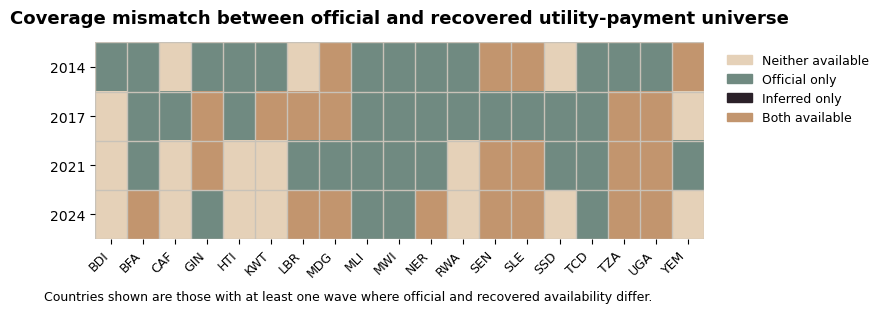

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# Keep only countries with at least one mismatch:
# 1 = official only, 2 = inferred only
mismatch_mask = coverage[waves].isin([1, 2]).any(axis=1)
coverage_mismatch = coverage[mismatch_mask].copy()

plot_data = coverage_mismatch.set_index('country_id')[waves].T

# Palette inspired by the butterfly reference
cmap = ListedColormap([
    '#E5D1B8',  # neither: soft beige
    '#708A81',  # official only: muted sage-teal
    '#2B2129',  # inferred only: dark plum
    '#C2956E',  # both: muted cinnamon/sand
])

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap.N
)

fig, ax = plt.subplots(
    figsize=(
        max(8, len(plot_data.columns) * 0.45),
        max(3, len(plot_data.index) * 0.75)
    )
)

im = ax.imshow(
    plot_data,
    aspect='auto',
    cmap=cmap,
    norm=norm
)

ax.set_xticks(range(len(plot_data.columns)))
ax.set_xticklabels(
    plot_data.columns,
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(
    plot_data.index,
    fontsize=10
)

# Tile boundaries
ax.set_xticks(
    np.arange(-0.5, len(plot_data.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(plot_data.index), 1),
    minor=True
)

ax.grid(
    which='minor',
    color='#C8C2B8',
    linestyle='-',
    linewidth=1.0
)

ax.tick_params(
    which='minor',
    bottom=False,
    left=False
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('')
ax.set_ylabel('')

ax.set_title(
    'Coverage mismatch between official and recovered utility-payment universe',
    fontsize=13,
    weight='bold',
    pad=14
)

legend_items = [
    mpatches.Patch(color='#E5D1B8', label='Neither available'),
    mpatches.Patch(color='#708A81', label='Official only'),
    mpatches.Patch(color='#2B2129', label='Inferred only'),
    mpatches.Patch(color='#C2956E', label='Both available'),
]

ax.legend(
    handles=legend_items,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    fontsize=9
)

fig.text(
    0.01,
    -0.02,
    'Countries shown are those with at least one wave where official and recovered availability differ.',
    fontsize=9
)

plt.tight_layout()
plt.show()

### Reconstruction error

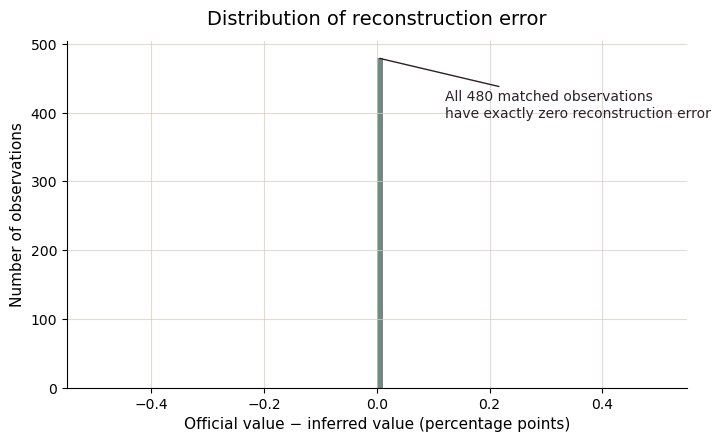

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    fin31_check_data['spread'],
    color='#708A81',
    bins=100
)

# labels
ax.set_title(
    'Distribution of reconstruction error',
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    'Official value − inferred value (percentage points)',
    fontsize=11
)

ax.set_ylabel(
    'Number of observations',
    fontsize=11
)

# styling
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(
    True,
    color='#D2CCC3',
    linewidth=0.8,
    alpha=0.7
)

# explanatory annotation
n_obs = len(fin31_check_data)

ax.annotate(
    f'All {n_obs} matched observations\nhave exactly zero reconstruction error',
    xy=(0, n_obs),
    xytext=(0.12, n_obs * 0.82),
    fontsize=10,
    color='#2B2129',
    arrowprops=dict(
        arrowstyle='-',
        color='#2B2129',
        lw=1
    )
)

# save the plot
plt.savefig(
    "../articles/additional_series/pic/reconstruction_error.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

# Examining the structure of additional data

Additional data, that is data for which population is shrunk to a subset, is represented in column UNIT_MEASURE.

The number of UNIT_MEASURE values is 34. PT_RESP denotes the population value and is shared between all 280 indicators present in the DB.

Each UNIT_MEASURE value is shared between indicators.

Each indicator has PT_RESP and up to one other value of UNIT_MEASURE. It means each indicator has up to one additional information about shrunk reference population.

### The number of shared indicators

In [26]:
unit_measure_tuples = utils.run_sql(findex_db_name, sql_folder + 'unit_measure.sql')
unit_measure_data = pd.DataFrame(unit_measure_tuples, columns = ['unit_measure', 'unit_measure_label', 'no_indicators'])

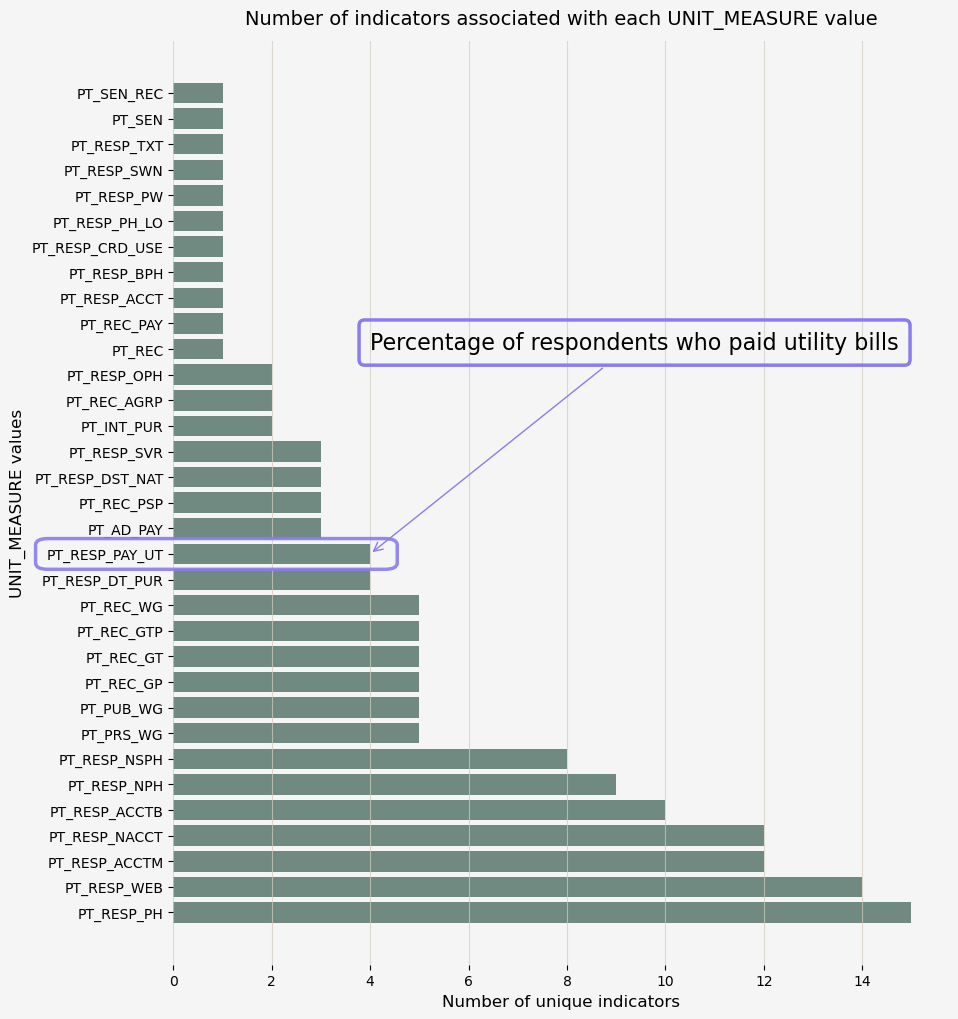

In [27]:
um_plot_data = unit_measure_data.query("unit_measure != 'PT_RESP'")

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(um_plot_data['unit_measure'], um_plot_data['no_indicators'],
       color = "#708A81")

# save the limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# labels
ax.set_title("Number of indicators associated with each UNIT_MEASURE value",
            fontsize = 14,
            pad = 12)
ax.set_xlabel("Number of unique indicators",
             fontsize = 12)
ax.set_ylabel("UNIT_MEASURE values",
             fontsize = 12)

# pretty stuff
# remove box borders
for spine in ['top', 'bottom', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# grid, only vertical bars
ax.grid( axis = 'x',
    color='#D2CCC3',
    linewidth=0.8,
    alpha=0.7
)

# background color
fig.patch.set_facecolor('whitesmoke')
ax.set_facecolor('whitesmoke')

# additional information
# highlight the value of interest PT_RESP_PAY_UT

# find the position of the value of interest
for i, (_, row) in enumerate(um_plot_data.iterrows()):
    if row["unit_measure"] == "PT_RESP_PAY_UT":
        y = i
        x = row["no_indicators"]
        break

HIGHLIGHT_COLOR = "#8A7CF0"

# rounded retangle arount the bar of interest
highlight = FancyBboxPatch(
    (-2.75, y - 0.55), # lower left corner
    x + 3.25, # width
    1.1, # height

    boxstyle = "round,pad=0.05,rounding_size=0.25",

    fill = False,
    edgecolor = HIGHLIGHT_COLOR,
    linewidth = 2.5,
    alpha = 0.9,

    clip_on = False, # draw even if outside axes
    zorder = 3
)
ax.add_patch(highlight)

ax.annotate(
    "Percentage of respondents who paid utility bills",
    xy = (x, y),
    xytext = (x, y + 8),
    # color = HIGHLIGHT_COLOR,
    fontsize = 16,
    bbox=dict(
        boxstyle = "round,pad=0.5,rounding_size=0.25",
        fc = "none",          # fill color
        ec = HIGHLIGHT_COLOR,        # edge color
        lw = 2.5
    ),
    arrowprops=dict(
        arrowstyle = "->",
        color = HIGHLIGHT_COLOR,
        lw = 1
    )
)

# restore the limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# save the plot
plt.savefig(
    "../articles/additional_series/pic/unit_measures.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

### Number of UNIT_MEASURE values for each indicator

PT_RESP is base population and each indicator has it.

In [28]:
assert utils.run_sql(findex_db_name, sql_folder + 'indicator_unique_unit_measure.sql') == []

# What is fin30.1 then?
## Sanity checks based on probability

### Import data

In [5]:
# import data for (country, date) for fin30, fin30.1 (women), and fin30.2 (men)
fin30_mf_tuples = utils.run_sql(countries_db_name, sql_folder + 'fin30_1_2.sql')
# val_diff is (sv_F.series_value + sv_M.series_value) - sv_base.series_value
fin30_mf_data = pd.DataFrame(fin30_mf_tuples, columns = ['country', 'observation_date', 'val_F', 'val_M', 'val_sum', 'val_pop', 'val_diff'])

assert not fin30_mf_data.empty

# extract year
fin30_mf_data['observation_date'] = pd.to_numeric(fin30_mf_data['observation_date'].str.slice(stop = 4))

# observations for 2021 wave were gathered in 2021 and 2022
# make 2021 wave consistent on observation date
fin30_mf_data.loc[fin30_mf_data['observation_date'] == 2022, 'observation_date'] = 2021

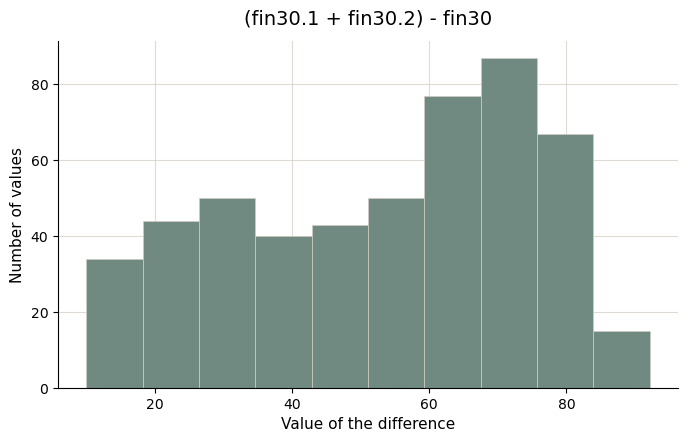

In [6]:
utils.pretty_histogram(fin30_mf_data['val_diff'],
                title = "(fin30.1 + fin30.2) - fin30",
                x_axis_title = "Value of the difference",
                y_axis_title = "Number of values",
                save_file_name = "../articles/additional_series/pic/differences.png")

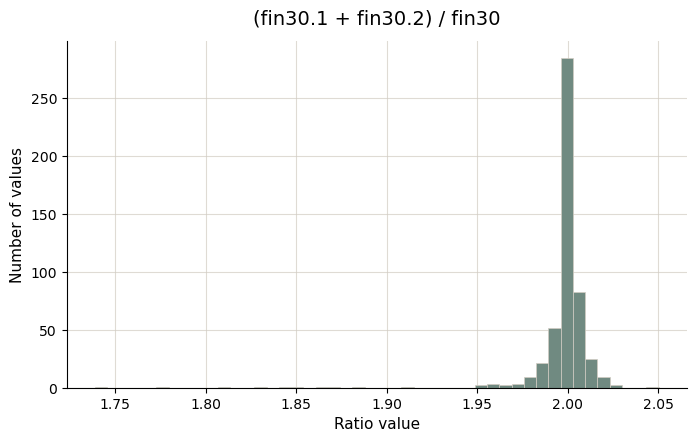

In [7]:
utils.pretty_histogram(fin30_mf_data['val_sum']/fin30_mf_data['val_pop'] ,
                title = "(fin30.1 + fin30.2) / fin30",
                x_axis_title = "Ratio value",
                y_axis_title = "Number of values",
                save_file_name = "../articles/additional_series/pic/ratio_base_difference.png")

In [8]:
# if fin30_mf_data['val_F'] = fin30_mf_data['val_M'],
# that is P(PB|F) == P(PB|M) the denominator for P(F) will be 0
assert (fin30_mf_data['val_F'] - fin30_mf_data['val_M'] == 0).sum() == 0

In [9]:
# percentage of surveyed women
# $$ P(F) = \frac{\mathbb{P}(PB) - \mathbb{P}(PB\mid M)}{\mathbb{P}(PB\mid F) - \mathbb{P}(PB\mid M)}$$
# $$ P(F) = \frac{\text{fin30} - \text{fin30.2}}{\text{fin30.1} - \text{fin30.2}} $$
fin30_mf_data['perc_women'] = (fin30_mf_data['val_pop'] - fin30_mf_data['val_M'])/(fin30_mf_data['val_F'] - fin30_mf_data['val_M'])

In [10]:
# check if percentages are correct values
assert ((fin30_mf_data['perc_women'] < 0) | (fin30_mf_data['perc_women'] > 1)).sum() == 0

In [11]:
# convert to percentages for consistency 
fin30_mf_data['perc_women'] = fin30_mf_data['perc_women'] * 100

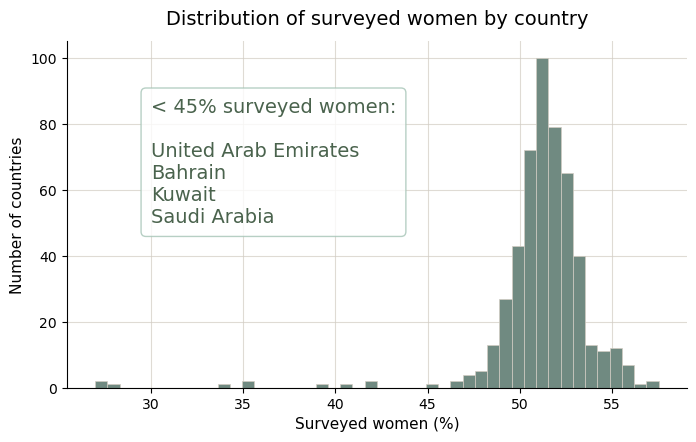

In [12]:
annotation_text = (
    "< 45% surveyed women:\n\n"
    "United Arab Emirates\n"
    "Bahrain\n"
    "Kuwait\n"
    "Saudi Arabia"
)

utils.pretty_histogram(fin30_mf_data['perc_women'] ,
                title = "Distribution of surveyed women by country",
                x_axis_title = "Surveyed women (%)",
                y_axis_title = "Number of countries",
                annotation={
                    "bbox": {
                            "boxstyle": "round,pad=0.5,rounding_size=0.25",
                            "fc": "white",          # fill color
                            "ec": "#a5c4b6",
                            "lw": 1,
                            "alpha": 0.8
                    },
                    "text": annotation_text,
                    "xy": (27, 2),
                    "xytext": (30, 50),
                    "color": "#4a634d",
                    "fontsize": 14
                },
                save_file_name = "../articles/additional_series/pic/percentage_women.png")

In [13]:
# inspect the outliers
fin30_mf_data[fin30_mf_data['perc_women'] < 45]

,country,observation_date,val_F,val_M,val_sum,val_pop,val_diff,perc_women
8,ARE,2014,26.859423,54.624444,81.483868,46.857367,34.626500,27.974324
9,ARE,2017,42.414579,58.915905,101.330485,54.386647,46.943838,27.447846
10,ARE,2021,24.624321,33.421265,58.045587,31.047645,26.997941,26.982328
47,BHR,2014,25.663490,45.605082,71.268572,38.557990,32.710582,35.338665
48,BHR,2017,29.646474,51.120224,80.766698,43.833938,36.932759,33.931127
248,KWT,2014,12.325291,22.402676,34.727967,18.194141,16.533826,41.762172
249,KWT,2017,13.313301,25.136693,38.449994,20.973111,17.476883,35.214787
396,SAU,2014,11.795914,51.309313,63.105227,34.818877,28.286349,41.733781
397,SAU,2017,13.929179,56.022997,69.952177,39.388506,30.563670,39.517657
398,SAU,2021,34.808186,66.196927,101.005113,53.506053,47.499060,40.431294


In [26]:
# population P(PB and F)
fin30_mf_data['PB_and_F'] = (fin30_mf_data['val_F']/100)*(fin30_mf_data['perc_women']/100)
# assert the range is valid for probability
assert ((fin30_mf_data['PB_and_F'] < 0) | (fin30_mf_data['PB_and_F'] > 1)).sum() == 0
# convert to percentages for consistency
fin30_mf_data['PB_and_F'] = fin30_mf_data['PB_and_F'] * 100

In [27]:
# P(F|PB)
fin30_mf_data['F|PB'] = fin30_mf_data['PB_and_F']/fin30_mf_data['val_pop']
# assert valid probability range
assert ((fin30_mf_data['F|PB'] < 0) | (fin30_mf_data['F|PB'] > 1)).sum() == 0
# convert to percentages for consistency
fin30_mf_data['F|PB'] = fin30_mf_data['F|PB'] * 100

### Plot data
max(P(PB and F)) will sit somewhere below 60%. It is bounded by the percentage of women in the population and here, strictly by the percentage of surveyed women.
It's not useful to use the came color palette as for values spanning 0-100% not to create confusion of sameness.

In [82]:
P_and_F_palette = [
    '#C6B1B0',
    '#98A975',
    '#47906B',
    '#0B5F6A',
    '#162937'
]
P_and_F_palette = [
    '#bcc656',
    '#75983c',
    '#6376bb',
    '#75518A',
    '#473356'
]
P_and_F_palette = [
    '#cfb5c7',
    '#946186',
    '#8f8f8f',
    '#31a9c1',
    '#1237c3'
]

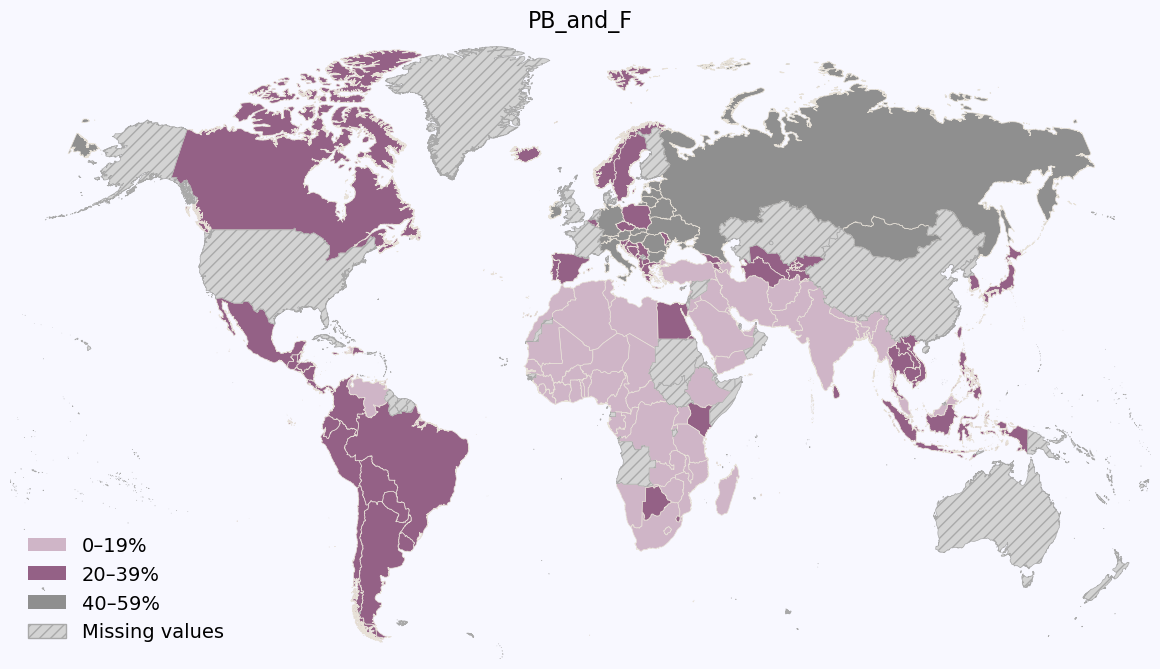

In [214]:
plot_buckets_countries(5, fin30_mf_data[['country', 'observation_date', 'PB_and_F']], 'PB_and_F', P_and_F_palette, 'PB_and_F')

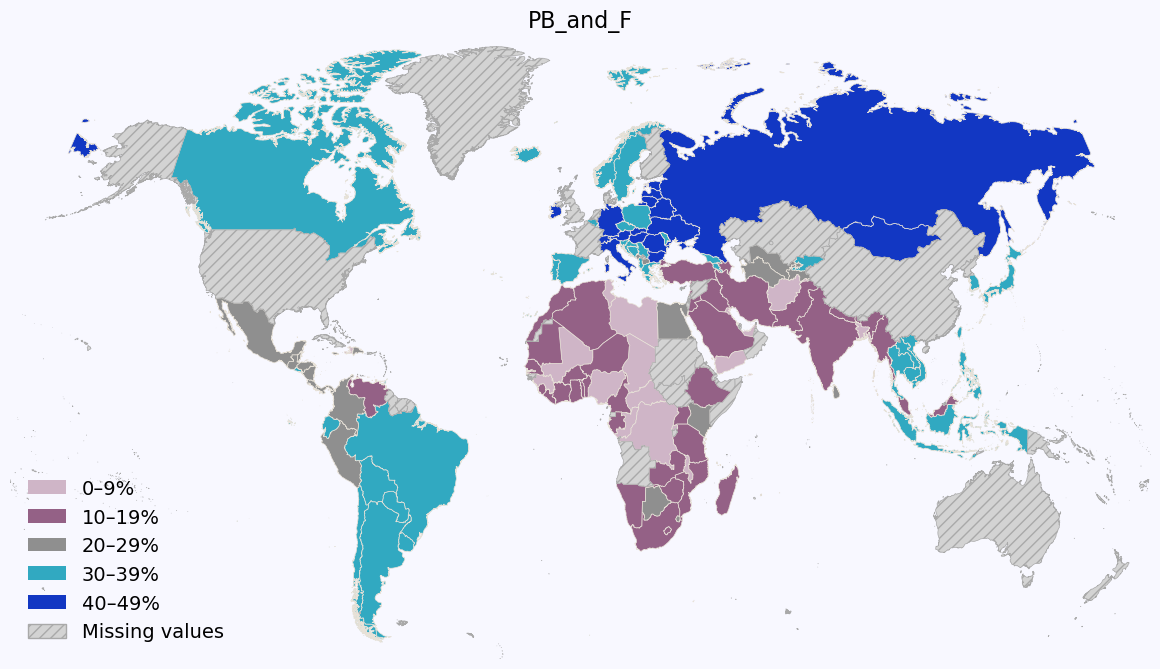

In [215]:
plot_buckets_countries(10, fin30_mf_data[['country', 'observation_date', 'PB_and_F']], 'PB_and_F', P_and_F_palette, 'PB_and_F')

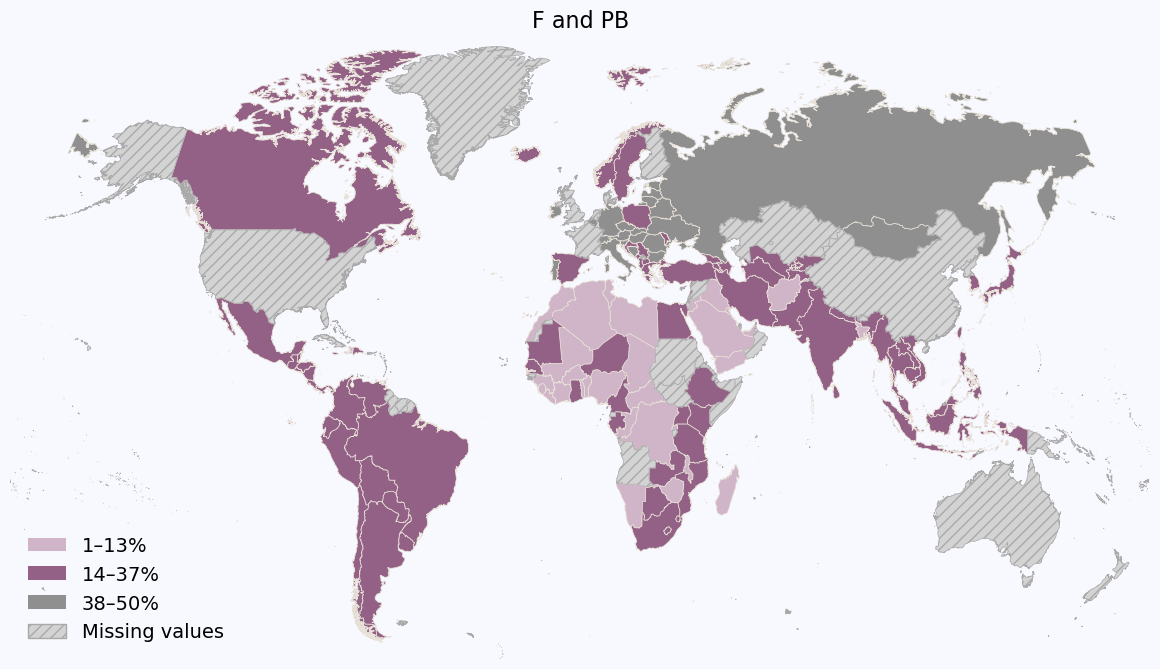

In [254]:
plot_Gaussian_buckets_countries(fin30_mf_data[['country', 'observation_date', 'PB_and_F']], 'PB_and_F', P_and_F_palette, 'F and PB')

In [248]:
P_mid_F_palette = [
    '#bcc656',
    '#75983c',
    '#6376bb',
    '#4d5084',
    '#75518A',
    '#473356'
]
P_mid_F_palette = [
    '#7d9e8d',
    '#C6B1B0',
    '#98A975',
    '#47906B',
    '#0B5F6A',
    '#162937'
]
P_mid_F_palette = [
    '#309024',
    '#024F49',
    #'#0b5f6a',
    '#47906b',
    '#a5c4b6',
    '#71518a',
    '#473356'
]
P_mid_F_palette = [
    '#162937',
    '#0b5f6a',
    '#44a288',
    #'#83c2a3',
    '#a5c4b6',
    '#6376bb',
    '#141b8f'
]

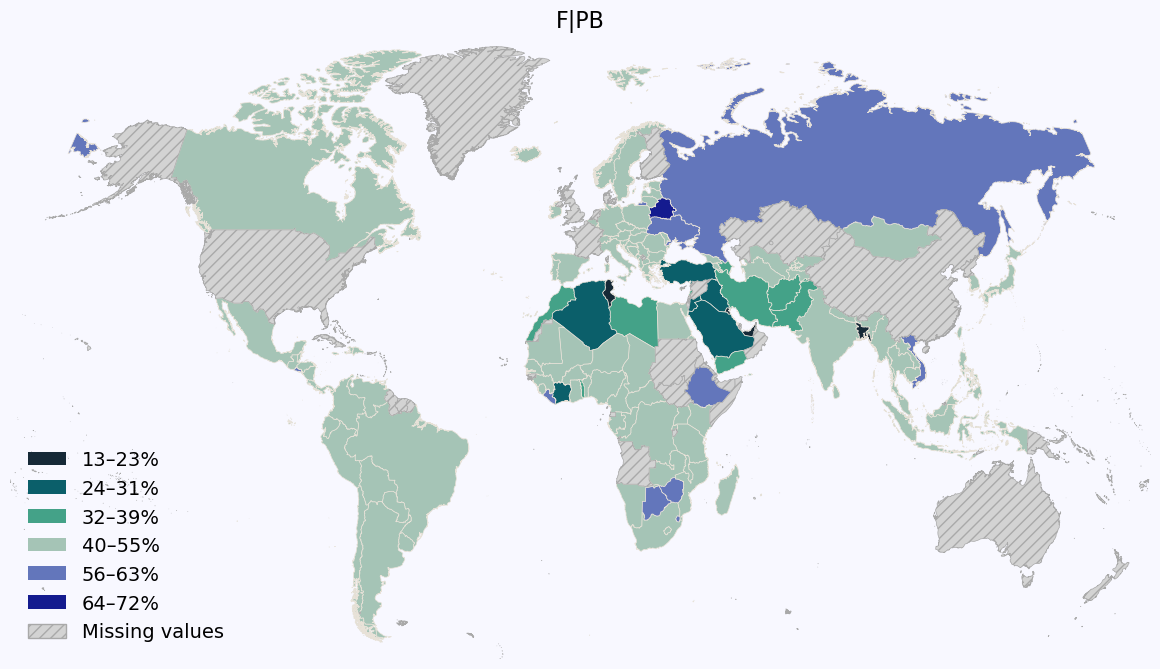

In [249]:
plot_Gaussian_buckets_countries(fin30_mf_data[['country', 'observation_date', 'F|PB']], 'F|PB', P_mid_F_palette, 'F|PB')

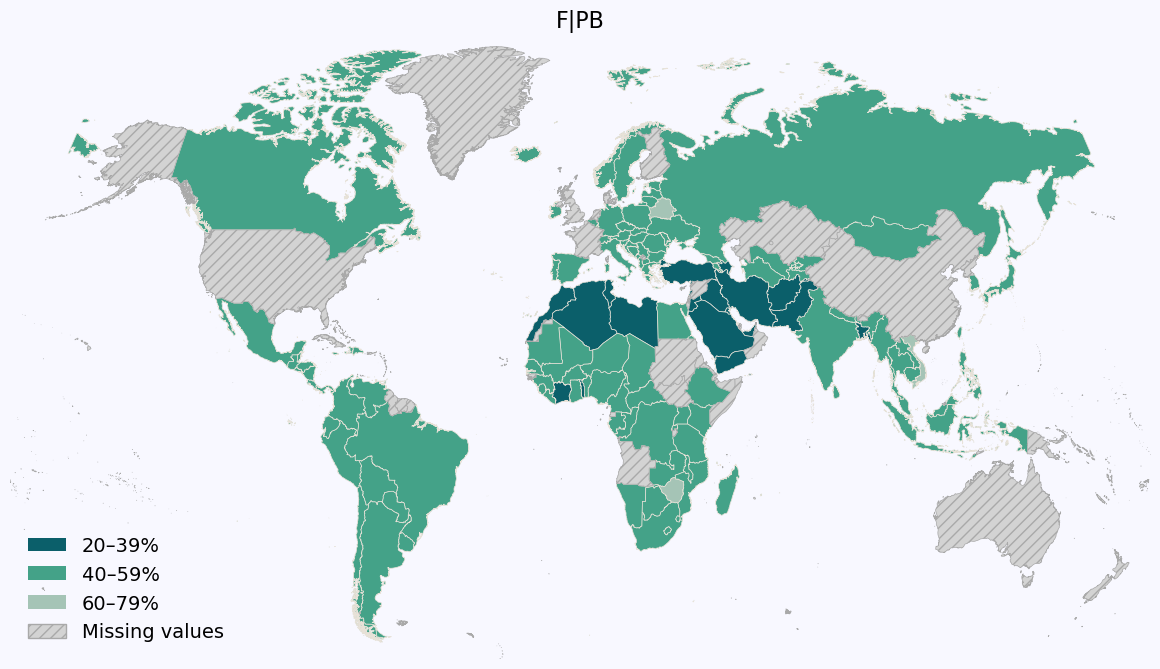

In [250]:
plot_buckets_countries(5, fin30_mf_data[['country', 'observation_date', 'F|PB']], 'F|PB', P_mid_F_palette, 'F|PB')

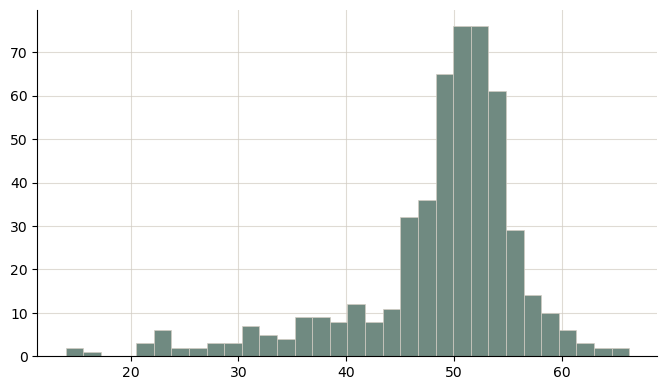

In [99]:
utils.pretty_histogram(fin30_mf_data['F|PB'])

Utility bill payment rates vary dramatically across the globe. The gender composition of bill payers varies much less, but not randomly. Countries in the Middle East and parts of North Africa tend to have a lower share of women among bill payers, while several former Soviet countries exhibit the opposite pattern.

In [252]:
mu = fin30_mf_data['F|PB'].mean()
sigma = fin30_mf_data['F|PB'].std()

print(mu)
print(sigma)
factor = 2
left = mu - factor * sigma
right = mu + factor * sigma
print(left)
print(right)

fin30_mf_data_below_sd = fin30_mf_data[(fin30_mf_data['F|PB'] < left)]
fin30_mf_data_above_sd = fin30_mf_data[(fin30_mf_data['F|PB'] > right)]

print(fin30_mf_data_below_sd['country'].unique())
print(fin30_mf_data_above_sd['country'].unique())

48.589651877547944
7.952121127228202
32.68540962309154
64.49389413200434
['ARE' 'BGD' 'BHR' 'CIV' 'DZA' 'IRQ' 'JOR' 'KWT' 'PAK' 'PSE' 'SAU' 'SEN'
 'TUN' 'TUR' 'YEM']
['BLR' 'VNM']
